# Open Data Cube   
The Open Data Cube (ODC) is an open source solution for accessing, managing, and analyzing large quantities of Geographic Information System (GIS) data - namely Earth Observation (EO) data. It presents a common analytical framework composed of a series of data structures and tools which facilitate the organization and analysis of large gridded data collections.

Open Data Cube 是一個開源的觀測資料管理與分析框架。它可用來管理大量地球觀測資料，並透過Python API來進行資料存取、快速查詢與全球尺度的資料分析。

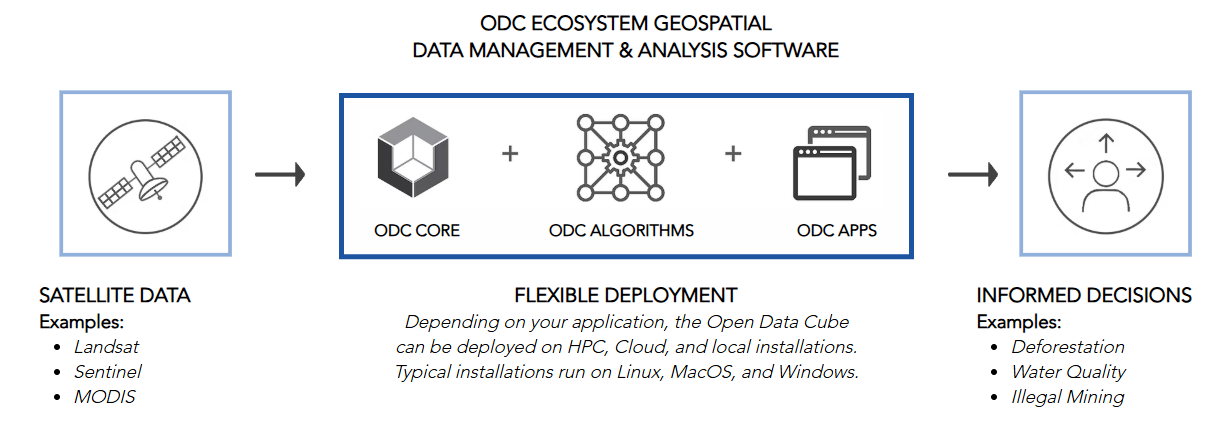
Source: [ODC_overview](https://www.opendatacube.org/overview-draft)

## ODC Sentinel-2 Land-Cover Load Demo

This notebook loads a fixed Greater Taipei bounding box from the indexed Taiwan Sentinel-2-derived annual land-cover GeoTIFFs.

`x` and `y` are projected raster coordinates in EPSG:32651. The plot below relabels ticks as longitude and latitude for readability. The land-cover class codes are stored in the `classification` data variable. NoData is class `0`.

In [ ]:
from datacube import Datacube
from rasterio.warp import transform, transform_bounds
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.patches as mpatches

PRODUCT = "s2_landcover_taiwan"
MEASUREMENT = "classification"
OUTPUT_CRS = "EPSG:32651"
RESOLUTION = (-10, 10)

dc = Datacube(app="01_odc_load_demo")

In [ ]:
dc.list_products().loc[[PRODUCT]]

,name,description,license,default_crs,default_resolution
name,,,,,
s2_landcover_taiwan,s2_landcover_taiwan,Sentinel-2-derived 10 m annual land-use/land-c...,None,None,None


In [ ]:
datasets = list(dc.index.datasets.search(product=PRODUCT))
len(datasets), datasets[:1]

(4,
 [Dataset <id=7e8e3233-da13-541e-b816-d3aab6294d63 product=s2_landcover_taiwan location=file:///workspace/datasets/51R_20170101-20180101.yaml>])

## Taipei Bounding Box

The bbox below is a focused Taipei core area in lon/lat. It is transformed to EPSG:32651 before loading from ODC.

In [ ]:
# Greater Taipei core bbox: west, south, east, north in EPSG:4326
# Use a focused bbox for an interactive notebook; expand only when needed.
taipei_bbox_lonlat = (121.40, 24.95, 121.70, 25.20)

min_x, min_y, max_x, max_y = transform_bounds(
    "EPSG:4326",
    OUTPUT_CRS,
    *taipei_bbox_lonlat,
    densify_pts=21,
)

taipei_query = {
    "x": (min_x, max_x),
    "y": (min_y, max_y),
}
taipei_query

{'x': (338465.5672824149, 369023.31320660067),
 'y': (2760039.469637457, 2788052.3009832525)}

In [ ]:
taipei = dc.load(
    product=PRODUCT,
    measurements=[MEASUREMENT],
    x=taipei_query["x"],
    y=taipei_query["y"],
    crs=OUTPUT_CRS,
    output_crs=OUTPUT_CRS,
    resolution=RESOLUTION,
)
taipei

<xarray.Dataset> Size: 34MB
Dimensions:         (time: 4, y: 2802, x: 3057)
Coordinates:
  * time            (time) datetime64[ns] 32B 2017-07-02T12:00:00 ... 2020-07-02
  * y               (y) float64 22kB 2.788e+06 2.788e+06 ... 2.76e+06 2.76e+06
  * x               (x) float64 24kB 3.385e+05 3.385e+05 ... 3.69e+05 3.69e+05
    spatial_ref     int32 4B 32651
Data variables:
    classification  (time, y, x) uint8 34MB 1 1 1 1 1 1 1 1 ... 2 2 2 2 2 2 2 2
Attributes:
    crs:           EPSG:32651
    grid_mapping:  spatial_ref

In [ ]:
classification = taipei[MEASUREMENT]
classification

<xarray.DataArray 'classification' (time: 4, y: 2802, x: 3057)> Size: 34MB
array([[[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [7, 7, 7, ..., 2, 2, 2],
        [7, 7, 7, ..., 2, 2, 2],
        [7, 7, 7, ..., 2, 2, 2]],

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [7, 7, 7, ..., 2, 2, 2],
        [7, 7, 7, ..., 2, 2, 2],
        [7, 7, 7, ..., 2, 2, 2]],

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [7, 7, 7, ..., 2, 2, 2],
        [7, 7, 7, ..., 2, 2, 2],
        [7, 7, 7, ..., 2, 2, 2]],

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [7, 7, 7, ..., 2, 2, 2],
        [7, 7, 7, ..., 2, 2, 2],
        [7, 7, 7, ..., 2, 2, 2]]], shape=(4, 2802, 3057), dtype=uint8)
Coordinates:
  * time         (time) datetime64[ns] 32B 2017-07-02T12:00:00 ... 2020-07-02
  * y            (y) float64 22kB 2.788e+06 2.788e+06 ... 2.76e+06 2.76e+06
  * x            (x) float64 24kB 3.385e+05 3.385e+05 ... 3.69e+05 3.69e+05
    spatial_ref  int32 4B 32651
Attributes:
    units:         1
    nodata:        0
    crs:           EPSG:32651
    grid_mapping:  spatial_ref

## Area Summary

This avoids converting the full raster to a pandas Series. It counts each class directly with NumPy, then creates a small summary table.

In [ ]:
class_names = {
    1: "Water",
    2: "Trees",
    4: "Flooded Vegetation",
    5: "Crops",
    7: "Built Area",
    8: "Bare Ground",
    9: "Snow/Ice",
    10: "Clouds",
    11: "Rangeland",
}

pixel_area_m2 = 100
class_codes = list(class_names)

rows = []
for time_value in classification.time.values:
    arr = classification.sel(time=time_value).values
    for code in class_codes:
        pixel_count = int(np.count_nonzero(arr == code))
        rows.append(
            {
                "time": str(time_value)[:10],
                "class_code": code,
                "class_name": class_names[code],
                "pixel_count": pixel_count,
                "area_km2": pixel_count * pixel_area_m2 / 1_000_000,
            }
        )

area = pd.DataFrame(rows)
area

,time,class_code,class_name,pixel_count,area_km2
0,2017-07-02,1,Water,384576,38.4576
1,2017-07-02,2,Trees,4073450,407.3450
2,2017-07-02,4,Flooded Vegetation,8254,0.8254
3,2017-07-02,5,Crops,57679,5.7679
4,2017-07-02,7,Built Area,3841570,384.1570
5,2017-07-02,8,Bare Ground,4705,0.4705
6,2017-07-02,9,Snow/Ice,0,0.0000
7,2017-07-02,10,Clouds,7287,0.7287
8,2017-07-02,11,Rangeland,188193,18.8193
9,2018-07-02,1,Water,384897,38.4897


## Plot

The plot uses one time slice and decimates pixels for display only. The raster is still loaded in EPSG:32651, but axis tick labels are converted back to longitude and latitude.

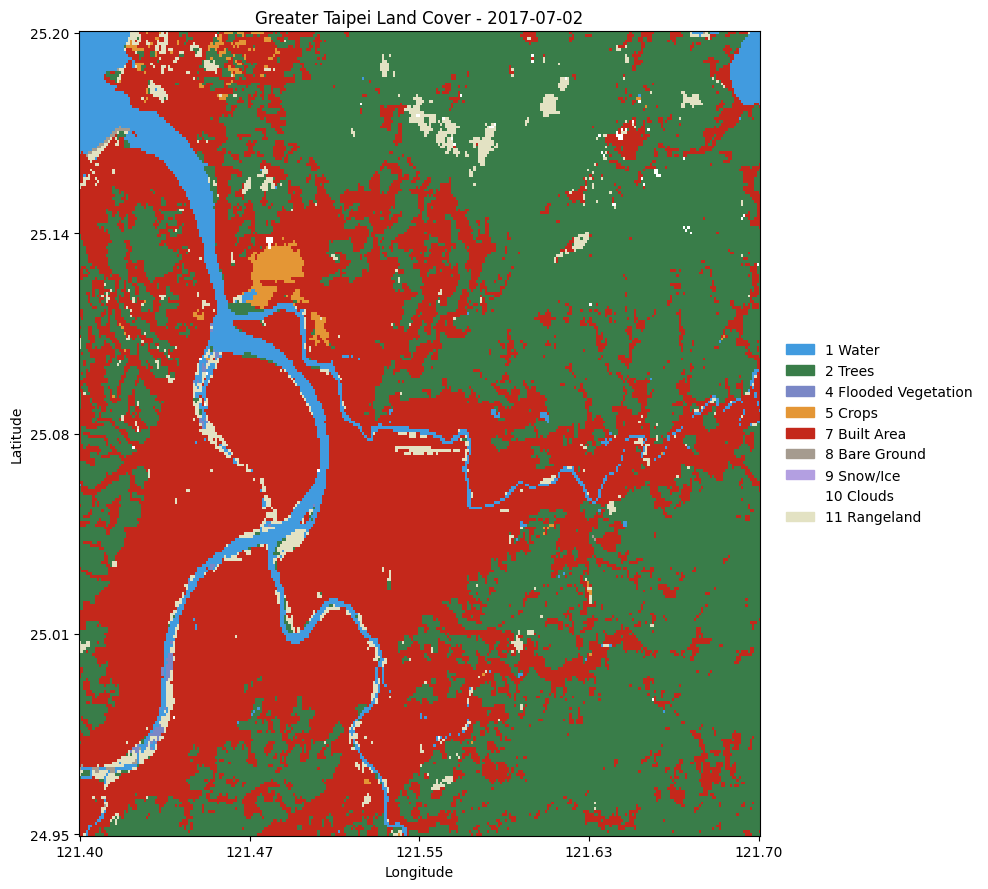

In [ ]:
class_colors = {
    1: "#419BDF",
    2: "#397D49",
    4: "#7A87C6",
    5: "#E49635",
    7: "#C4281B",
    8: "#A59B8F",
    9: "#B39FE1",
    10: "#FFFFFF",
    11: "#E3E2C3",
}

codes = list(class_colors)
bounds = [0.5, 1.5, 2.5, 4.5, 5.5, 7.5, 8.5, 9.5, 10.5, 11.5]
cmap = ListedColormap([class_colors[code] for code in codes])
norm = BoundaryNorm(bounds, cmap.N)


def set_lonlat_ticks(ax, x_values, y_values, x_count=5, y_count=5):
    x_ticks = np.linspace(float(x_values.min()), float(x_values.max()), x_count)
    y_ticks = np.linspace(float(y_values.min()), float(y_values.max()), y_count)
    center_x = float(x_values.mean())
    center_y = float(y_values.mean())

    lon_labels, _ = transform(OUTPUT_CRS, "EPSG:4326", x_ticks.tolist(), [center_y] * len(x_ticks))
    _, lat_labels = transform(OUTPUT_CRS, "EPSG:4326", [center_x] * len(y_ticks), y_ticks.tolist())

    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    ax.set_xticklabels([f"{lon:.2f}" for lon in lon_labels])
    ax.set_yticklabels([f"{lat:.2f}" for lat in lat_labels])


plot_time_index = 0
display_step = 10

plot_data = classification.isel(time=plot_time_index)
plot_data = plot_data.where(plot_data != 0)
plot_data = plot_data.isel(y=slice(None, None, display_step), x=slice(None, None, display_step))

fig, ax = plt.subplots(figsize=(10, 9))
plot_data.plot.imshow(ax=ax, cmap=cmap, norm=norm, add_colorbar=False)
set_lonlat_ticks(ax, plot_data.x, plot_data.y)

time_value = str(classification.time.values[plot_time_index])[:10]
ax.set_title(f"Greater Taipei Land Cover - {time_value}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

patches = [
    mpatches.Patch(color=class_colors[code], label=f"{code} {class_names[code]}")
    for code in codes
]
ax.legend(handles=patches, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
plt.show()